# Heart Disease Prediction System

## Introduction

### Definition
A binary classification machine learning task that predicts whether a person has heart disease or not using selected medical attributes.

### Application
This system is developed for learning machine learning classification and understanding the relationship between medical attributes and heart disease.

## Input and Output

### Inputs (Features / Attributes)

| Input Feature / Attribute | Description |
|---|---|
| **Chest Pain (cp)** | Type of chest pain |
| **Major Vessels (ca)** | Number of major vessels colored by fluoroscopy |
| **Thalassemia (thal)** | Thalassemia category |
| **ST Depression (oldpeak)** | ST depression induced by exercise |

### Output (Prediction)

| Output Attribute | Possible Values |
|---|---|
| **Heart Disease** | No, Yes |

### Step 1: Import Libraries

In [1]:
%pip install prettytable

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [11]:
import numpy as np
import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from prettytable import PrettyTable

import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load Sample Data

In [13]:
sample_data = pd.read_csv("processed.cleveland.csv")

print("\nHeart Disease Sample Data:")
print("==========================\n")
print(sample_data)


Heart Disease Sample Data:

     63.0  1.0  1.0.1  145.0  233.0  1.0.2  2.0  150.0  0.0  2.3  3.0 0.0.1  \
0    67.0  1.0    4.0  160.0  286.0    0.0  2.0  108.0  1.0  1.5  2.0   3.0   
1    67.0  1.0    4.0  120.0  229.0    0.0  2.0  129.0  1.0  2.6  2.0   2.0   
2    37.0  1.0    3.0  130.0  250.0    0.0  0.0  187.0  0.0  3.5  3.0   0.0   
3    41.0  0.0    2.0  130.0  204.0    0.0  2.0  172.0  0.0  1.4  1.0   0.0   
4    56.0  1.0    2.0  120.0  236.0    0.0  0.0  178.0  0.0  0.8  1.0   0.0   
..    ...  ...    ...    ...    ...    ...  ...    ...  ...  ...  ...   ...   
297  45.0  1.0    1.0  110.0  264.0    0.0  0.0  132.0  0.0  1.2  2.0   0.0   
298  68.0  1.0    4.0  144.0  193.0    1.0  0.0  141.0  0.0  3.4  2.0   2.0   
299  57.0  1.0    4.0  130.0  131.0    0.0  0.0  115.0  1.0  1.2  2.0   1.0   
300  57.0  0.0    2.0  130.0  236.0    0.0  2.0  174.0  0.0  0.0  2.0   1.0   
301  38.0  1.0    3.0  138.0  175.0    0.0  0.0  173.0  0.0  0.0  1.0     ?   

     6.0  0  
0    3.0

In [14]:
sample_data.columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "num"
]

print(sample_data.head())

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
1  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
2  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
3  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   
4  56.0  1.0  2.0     120.0  236.0  0.0      0.0    178.0    0.0      0.8   

   slope   ca thal  num  
0    2.0  3.0  3.0    2  
1    2.0  2.0  7.0    1  
2    3.0  0.0  3.0    0  
3    1.0  0.0  3.0    0  
4    1.0  0.0  3.0    0  


### Step 3: Understand and Pre-process Sample Data

#### Step 3.1: Understand Sample Data

In [15]:
print("Number of Rows and Columns:")
print(sample_data.shape)

print("\nColumn Names:")
print(sample_data.columns)

print("\nData Types:")
print(sample_data.dtypes)

print("\nMissing Values:")
print(sample_data.isnull().sum())

Number of Rows and Columns:
(302, 14)

Column Names:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

Data Types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
num           int64
dtype: object

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


#### Step 3.2: Pre-process Sample Data

In [21]:
sample_data = sample_data.replace("?", np.nan)

print("Missing values before preprocessing:")
print(sample_data.isnull().sum())

sample_data = sample_data.dropna()

print("\nMissing values after preprocessing:")
print(sample_data.isnull().sum())

Missing values before preprocessing:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Missing values after preprocessing:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


### Step 4: Feature Extraction

Four discriminating attributes are selected from the dataset:

1. Chest Pain Type (cp)
2. Number of Major Vessels (ca)
3. Thalassemia (thal)
4. ST Depression (oldpeak)

In [22]:
input_vectors = sample_data[["cp", "ca", "thal", "oldpeak"]]

print("Selected Input Features:")
print(input_vectors.head())

Selected Input Features:
    cp   ca thal  oldpeak
0  4.0  3.0  3.0      1.5
1  4.0  2.0  7.0      2.6
2  3.0  0.0  3.0      3.5
3  2.0  0.0  3.0      1.4
4  2.0  0.0  3.0      0.8


In [23]:
output_labels = sample_data["num"].apply(lambda x: 1 if x > 0 else 0)

print("\nOutput Labels:")
print(output_labels.head())


Output Labels:
0    1
1    1
2    0
3    0
4    0
Name: num, dtype: int64


### Step 6: Training Phase

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    input_vectors,
    output_labels,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (236, 4)
Testing data: (60, 4)


In [25]:
model = svm.SVC()

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


### Step 7: Testing Phase

In [26]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.95

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        36
           1       0.96      0.92      0.94        24

    accuracy                           0.95        60
   macro avg       0.95      0.94      0.95        60
weighted avg       0.95      0.95      0.95        60



### Step 8: Confusion Matrix

Confusion Matrix:
[[35  1]
 [ 2 22]]


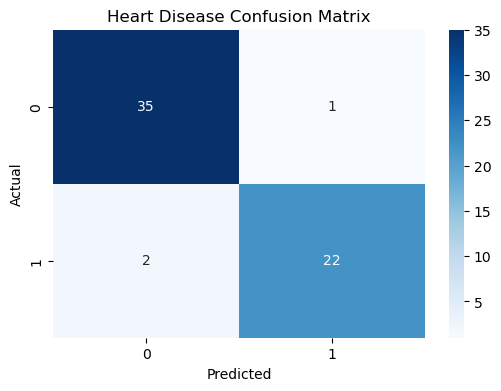

In [28]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Heart Disease Confusion Matrix")
plt.show()

### Step 9: Save Trained Model

In [29]:
with open("heart_disease_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully.")

Model saved successfully.


### Step 10: Heart Disease Prediction

In [31]:
print("Enter patient information:")

cp = float(input("Chest Pain (cp): "))
ca = float(input("Major Vessels (ca): "))
thal = float(input("Thalassemia (thal): "))
oldpeak = float(input("ST Depression (oldpeak): "))

patient_data = pd.DataFrame(
    [[cp, ca, thal, oldpeak]],
    columns=["cp", "ca", "thal", "oldpeak"]
)

prediction = model.predict(patient_data)

if prediction[0] == 1:
    print("\nPrediction: Heart Disease")
else:
    print("\nPrediction: No Heart Disease")

Enter patient information:


Chest Pain (cp):  1
Major Vessels (ca):  0
Thalassemia (thal):  3
ST Depression (oldpeak):  1.0



Prediction: No Heart Disease


In [32]:
%pip install flask

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
